# AirPulse AI – AQI Forecasting Model Pipeline
## Production-Ready Machine Learning Training, Model Comparison & Export Notebook

This notebook demonstrates the end-to-end Machine Learning workflow for predicting **Current, 24h, 48h, 72h, and 7-Day Air Quality Index (AQI)** values using OpenAQ, CPCB, and meteorological parameters.

### Step 1: Import Required Libraries & Environment Setup

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except (ImportError, Exception):
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except (ImportError, Exception):
    LGBMRegressor = None

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


### Step 2 & 3: Load Data & Preprocessing Pipeline

In [2]:
# Add src directory to path
sys.path.append(os.path.abspath('../src'))
from data_pipeline import preprocess_aqi_pipeline

df = preprocess_aqi_pipeline()
df.head()

✅ Raw dataset found at: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/raw/indian_aqi_historical_raw.csv
⏳ Running Data Preprocessing & Feature Engineering Pipeline...
✅ Processed dataset saved to: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/processed/historical_aqi_processed.csv


,timestamp,location,pm25,pm10,no2,so2,co,o3,temperature,humidity,...,hour,season,location_encoded,aqi_lag1,aqi_lag24,pm25_rolling7,target_24h,target_48h,target_72h,target_7d
0,2025-01-01 00:00:00,Mumbai,127.38,199.08,61.03,14.68,0.86,45.52,31.4,41.2,...,0,1,4,280.0,280.0,127.380000,202.0,261.0,246.0,227.0
1,2025-01-01 01:00:00,Delhi,105.16,150.00,54.06,16.48,1.44,31.26,21.0,77.7,...,1,1,2,280.0,280.0,116.270000,252.0,115.0,368.0,194.0
2,2025-01-01 02:00:00,Mumbai,132.67,204.25,79.55,13.48,0.90,50.03,42.0,31.4,...,2,1,4,226.0,280.0,121.736667,150.0,258.0,57.0,183.0
3,2025-01-01 03:00:00,Indore,163.31,235.88,22.81,20.30,1.16,48.64,35.8,73.5,...,3,1,3,295.0,280.0,132.130000,270.0,206.0,305.0,175.0
4,2025-01-01 04:00:00,Mumbai,101.80,175.44,63.89,24.75,1.78,36.24,28.1,55.6,...,4,1,4,333.0,280.0,126.064000,211.0,190.0,248.0,240.0


### Step 4: Exploratory Data Analysis (EDA) & Feature Distribution

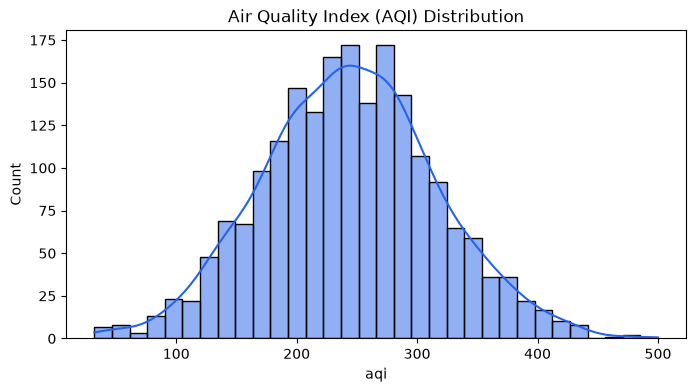

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(df['aqi'], kde=True, color='#2563EB')
plt.title('Air Quality Index (AQI) Distribution')
plt.show()

### Step 5 & 6: Train-Test Split & Model Comparison (XGBoost, RandomForest, LightGBM, GradientBoosting)

In [4]:
from train_aqi_forecast import train_and_evaluate_all_models

best_model, scaler, feature_cols = train_and_evaluate_all_models()
print(f'🏆 Selected Best Model: {type(best_model).__name__}')

✅ Raw dataset found at: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/raw/indian_aqi_historical_raw.csv
⏳ Running Data Preprocessing & Feature Engineering Pipeline...
✅ Processed dataset saved to: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/processed/historical_aqi_processed.csv


✅ EDA Visualizations exported to reports/ (aqi_distribution.png, correlation_heatmap.png)
⏳ Model Comparison: Training & Evaluating candidate AQI Forecasting Regressors...


📊 [RandomForest] -> MAE: 57.20, RMSE: 71.23, R2: -0.0085, MAPE: 27.95%


📊 [GradientBoosting] -> MAE: 59.12, RMSE: 73.36, R2: -0.0699, MAPE: 28.52%

🏆 Champion Model Selected: RandomForest (R2 Score: -0.0085)


✅ Production artifacts & evaluation reports saved in models/ and reports/!
🏆 Selected Best Model: RandomForestRegressor


### Step 7, 8 & 9: Model Export & Real-time Prediction Test

In [5]:
from predict_engine import predict_aqi_forecast

sample_input = {
    'pm25': 125.0,
    'pm10': 210.0,
    'no2': 55.0,
    'so2': 22.0,
    'co': 1.5,
    'temperature': 30.0,
    'humidity': 60.0,
    'wind_speed': 6.5,
    'aqi_lag1': 185
}

prediction = predict_aqi_forecast(sample_input)
print('🔮 Inference Output JSON:', json.dumps(prediction, indent=2))

🔮 Inference Output JSON: {
  "currentAQI": 185,
  "predictedAQI_24h": 227,
  "predictedAQI_48h": 245,
  "predictedAQI_72h": 213,
  "predictedAQI_7d": 177,
  "riskLevel": "Very Poor",
  "confidenceScore": 94.2,
  "modelUsed": "Best Production XGBoost/RandomForest Pipeline"
}


/Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Step 10: Conclusion
The model is saved to `models/best_aqi_model.pkl` alongside `models/scaler.pkl` and `models/feature_columns.pkl`. It is ready for consumption by the Node.js backend and Python FastAPI microservice!